# 인플루엔자 의사환자분율(ILI) 단기 예측 노트북

**모형**: SIR(절대습도·학교 반영) + GBM 앙상블 + 검출률 규칙  (2026 예측네트워크 워크숍 문제 1 제출 모형)

기점(cutoff)과 예측 기간을 넣으면 아래 결과가 나옵니다.
- 추정된 모수 (β 식 계수, 지연, 오차 등)
- 적합 결과와 β 분해 그림
- 7개 분위수 예측 (SIR / GBM / 앙상블)
- WIS 채점 (정답이 있는 과거 기점일 때)
- 예측 그림과 제출 양식 CSV

**폴더 구성** (이 노트북과 같은 폴더에 둘 것)

| 파일 | 역할 |
|---|---|
| `core.py` | 자료 읽기·기점 자르기, 주차 계산, WIS·기준모형 |
| `joint.py` | SIR 모형: 모수 추정(IF2), 입자필터, 예측 |
| `stat_model.py` | GBM 분위수 모형 |
| `run_joint.py` | 검출률 규칙 함수(`pos_rule`) |
| `인플루엔자_학습_데이터.xlsx` | 질병청 학습 자료 (ILI, 검출률) |
| `features_weekly.csv` | 외부 자료를 주별로 정리한 파일 (절대습도, 수업주, 연휴주) |

위에서부터 셀을 하나씩 실행하면 됩니다.

## 0. 준비: 라이브러리와 파일 경로

In [8]:
import piplite

await piplite.install([
    "numpy",
    "pandas",
    "matplotlib",
    "openpyxl",
    "scikit-learn"
])

In [9]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.getcwd())          # 같은 폴더의 .py 모듈을 불러오기 위함

def find(fname):
    """파일 찾기: 노트북 폴더 → /mnt/user-data/uploads 순서"""
    for d in [".", "/mnt/user-data/uploads"]:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{fname} 을(를) 노트북 폴더에 넣어 주세요")

FLU_XLSX = find("인플루엔자 학습 데이터.xlsx")   # 질병청 학습 자료 (ILI, 검출률 등)
FEAT_CSV = find("features_weekly.csv")            # 외부 자료 주별 feature (절대습도, 수업주, 연휴주)
print(FLU_XLSX, FEAT_CSV, sep="\n")

./인플루엔자 학습 데이터.xlsx
./features_weekly.csv


## 1. feature CSV 읽기

`features_weekly.csv`의 열은 이렇습니다.

| 열 | 내용 | 쓰는 곳 |
|---|---|---|
| `년주` | 질병청 주차 (YYYYWW) | |
| `AH`, `AHz` | 주 평균 절대습도(g/m³), 표준화 값 (AH−10)/5 | β 식 (1주 시차) |
| `수업주` | 1 = 수업 주, 0 = 방학 또는 설·추석 주 | β 식 |
| `연휴주` | 설·추석이 낀 주 = 1 | 관측오차 확대, GBM 특징 |

달력 열은 2027년까지 채워져 있어 예측 기간에도 쓰입니다. 절대습도는 관측된 주까지만 있고, 기점 이후는 모형이 과거 같은 주차 평균으로 채웁니다.

In [10]:
feat = pd.read_csv(FEAT_CSV, encoding="utf-8-sig")
feat.tail(8)

,년주,주시작일,AH,AHz,수업주,연휴주
618,202744,2027-10-31,NaN,NaN,1,0
619,202745,2027-11-07,NaN,NaN,1,0
620,202746,2027-11-14,NaN,NaN,1,0
621,202747,2027-11-21,NaN,NaN,1,0
622,202748,2027-11-28,NaN,NaN,1,0
623,202749,2027-12-05,NaN,NaN,1,0
624,202750,2027-12-12,NaN,NaN,1,0
625,202751,2027-12-19,NaN,NaN,1,0


## 2. feature를 모형에 연결

모형 코드(`joint.py`, `stat_model.py`)가 이 CSV의 값을 쓰도록 연결합니다.
달력 정보를 먼저 바꾼 뒤 `joint`, `stat_model`을 불러와야 연휴 정보가 반영됩니다.

In [11]:
import core

# 달력: core의 학교·연휴 정보를 CSV 값으로 교체
SCHOOL = dict(zip(feat["년주"], feat["수업주"]))
core.school_flag = lambda yw: int(SCHOOL.get(int(yw), 1))
core.HOLIDAY = set(feat.loc[feat["연휴주"] == 1, "년주"].astype(int))

import joint, stat_model, run_joint      # 반드시 위 설정 뒤에 불러옴

# 절대습도: 모형 입력 형식(yw, T, Tz)으로 변환 — T는 원값, Tz는 표준화 값
AH_W = (feat.dropna(subset=["AH"])
            .rename(columns={"년주": "yw", "AH": "T", "AHz": "Tz"})[["yw", "T", "Tz"]])
print("연결 완료 — 절대습도", len(AH_W), "주, 연휴 주", len(core.HOLIDAY), "개")

연결 완료 — 절대습도 560 주, 연휴 주 30 개


## 3. 입력: 기점(cutoff)과 예측 기간

- `CUTOFF`: 이 주까지의 자료만 씁니다 (그 뒤 자료는 읽을 때 잘라냄)
- `HORIZON`: 몇 주 앞까지 예측할지

`BEST`는 2016~2022 기점 24개 검증으로 고른 최종 설정입니다.

In [21]:
CUTOFF  = 202541        # 예: 1-가 A=202337, B=202541, C=202450 / 1-나=202634 / 1-다=202639
HORIZON = 5

BEST = dict(sir_weight=0.8,      # 평소 SIR 가중 (나머지 GBM)
            rule_T=8.0,          # 검출률 규칙: 기점 검출률 < 8% 이고
            rule_D=1.0,          #             2주 전 대비 상승 ≤ 1%p 이면
            w_low=0.2,           #             SIR 가중을 0.2로 낮춤
            J=1500, M=60, reps=3)  # IF2 입자 수, 반복 수, 다중 시작 수

## 4. 자료 확인: 기점까지의 ILI와 검출률

,yw,ILI,ARI,pos,holiday
505,202536,6.6,23,2.3,False
506,202537,6.7,34,1.5,False
507,202538,8.0,43,2.1,False
508,202539,9.0,47,3.0,False
509,202540,12.1,33,7.1,False
510,202541,14.5,47,8.1,True


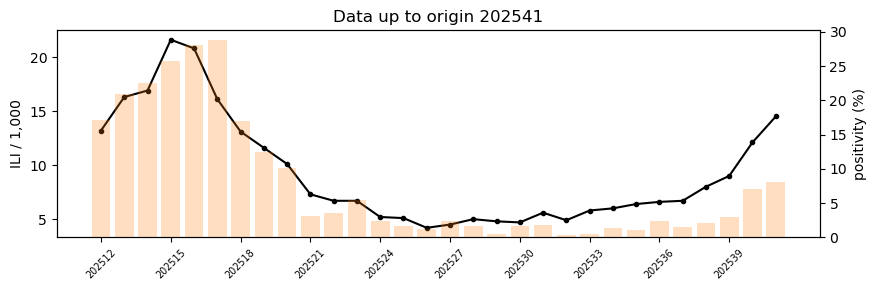

In [22]:
df = core.load_data(FLU_XLSX, origin=CUTOFF)               # 기점 이후 자료 차단

fig, ax = plt.subplots(figsize=(9, 3))
t = df.tail(30); x = np.arange(len(t))
ax.plot(x, t["ILI"], "k.-", label="ILI")
ax2 = ax.twinx(); ax2.bar(x, t["pos"], alpha=.25, color="C1", label="positivity %")
ax.set_xticks(x[::3]); ax.set_xticklabels(t["yw"].values[::3], rotation=45, fontsize=7)
ax.set_ylabel("ILI / 1,000"); ax2.set_ylabel("positivity (%)")
ax.set_title(f"Data up to origin {CUTOFF}"); fig.tight_layout()
t[["yw", "ILI", "ARI", "pos", "holiday"]].tail(6)

## 5. SIR 모형 적합 (약 1분)

1. IF2로 β 식 계수(θ₀, 절대습도, 학교), 감염→진료 지연 w, 오차 크기와 절기별 초기값(S₀, I₀)을 **ILI 우도 하나로 동시 추정**
2. 추정값으로 입자필터를 돌려 기점의 감염 상태(S, I, η) 추정
3. 거기서 `HORIZON`주를 시뮬레이션해 예측 표본 생성 (시작점 3개의 결과를 합침)

In [ ]:
t0 = time.time()
sir = joint.run_origin(FLU_XLSX, AH_W, CUTOFF, J=BEST["J"], M=BEST["M"], reps=BEST["reps"],
                       horizon=HORIZON)
print(f"SIR 적합 완료: {time.time() - t0:.0f}초")

## 6. 추정된 모수

| 모수 | 뜻 |
|---|---|
| θ₀ | 기준 전파율 (log β) |
| θ_AH | 절대습도 효과: 표준화 1단위(5 g/m³)당 log β 변화. 음수 = 건조할수록 전파 증가 |
| θ_S | 수업 주 효과 |
| σ_η | 설명 안 되는 전파 변동 η의 크기 |
| w | 이번 주 감염 중 같은 주 ILI에 잡히는 비율 (지연) |
| σ_b | 관측오차 중 수준에 비례하는 부분 |
| S₀ (현재) | 현재 구간 시작 시 감수성 비율 (κ 고정이라 상대적 의미만) |
| b | 비인플루엔자 기저 ILI |

In [ ]:
e = sir["best"]["est"]
params = pd.DataFrame({
    "모수": ["θ0", "θ_AH", "θ_S", "σ_η", "w", "σ_b", "S0(현재)", "기저 b", "로그우도"],
    "추정값": [e["theta0"], e["thetaT"], e["thetaS"], np.exp(e["log_sig"]), joint.expit(e["logit_w"]),
             np.exp(e["log_sigb"]), float(np.median(e["S0"][-1])), sir["b"], sir["best"]["ll"]],
    "해석": [f"기준 β={np.exp(e['theta0']):.2f}/일 → R0≈{np.exp(e['theta0'])*3:.2f}",
            f"5 g/m³ 건조해지면 β ×{np.exp(-e['thetaT']):.2f}",
            f"수업 주 β ×{np.exp(e['thetaS']):.2f}",
            "", "같은 주 비율", "", "", "외래 1,000명당", ""]})
params.round(3)

## 7. 적합 결과와 β 분해 (현재 구간)

- 왼쪽: 관측 ILI와 모형 적합값 (인플루엔자 몫 + 기저)
- 가운데: log β를 절대습도 몫, 학교 몫, 설명 안 되는 몫(η)으로 분해
- 오른쪽: 유효재생산수 (1을 넘으면 증가)

In [ ]:
h = sir["best"]["hist"].copy()
h["school"] = e["thetaS"] * np.array([core.school_flag(w) for w in h["yw"]])
x = np.arange(len(h)); lab = [str(w) for w in h["yw"]]

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].plot(x, h["y"], "k.-", label="observed ILI")
ax[0].plot(x, h["flu_med"] + sir["b"], "C0-", label="fitted (flu + baseline)")
ax[0].set_title("Fit"); ax[0].legend(fontsize=8)
ax[1].plot(x, h["tempT"], "C3-", label="abs. humidity")
ax[1].plot(x, h["school"], "C1--", label="school")
ax[1].plot(x, h["eta_med"], "C2-", label="eta (unexplained)")
ax[1].axhline(0, color="k", lw=.5); ax[1].set_title("log beta components"); ax[1].legend(fontsize=8)
ax[2].plot(x, h["Reff_med"], "k-"); ax[2].axhline(1, color="r", ls=":"); ax[2].set_title("R_eff")
for a in ax:
    a.set_xticks(x[::3]); a.set_xticklabels(lab[::3], rotation=45, fontsize=7)
fig.tight_layout()

## 8. GBM 예측, 검출률 규칙, 앙상블

- **GBM**: 과거에 비슷한 상황에서 ILI가 몇 % 움직였는지를 분위수별로 학습
- **검출률 규칙**: "ILI는 오르는데 검출률은 오르지 않는" 기점이면 SIR(인플루엔자 기전) 비중을 낮춤
- **앙상블**: 분위수끼리 가중 평균

In [ ]:
gbm = stat_model.forecast(sir["df"], AH_W, horizon=HORIZON)
qc = [c for c in sir["fc"].columns if c.startswith("q")]
q_sir, q_gbm = sir["fc"][qc].values, gbm[qc].values

rule = run_joint.pos_rule(sir["df"], T=BEST["rule_T"], D=BEST["rule_D"])
w = BEST["w_low"] if rule else BEST["sir_weight"]
q_ens = np.maximum.accumulate(w * q_sir + (1 - w) * q_gbm, axis=1)     # 분위수 순서 보장
print(f"검출률 규칙 {'작동' if rule else '미작동'} → SIR {w} + GBM {1 - w:.1f}")

weeks = sir["fc"]["target_week"].astype(int).tolist()
table = pd.DataFrame(q_ens, index=weeks, columns=core.QLEVELS).round(1)
table.index.name = "목표 주"
table

## 9. WIS 채점 (정답이 자료에 있는 과거 기점만)

- **WIS**: 분위수 예측의 벌점 (낮을수록 좋음)
- **상대 WIS** = 우리 WIS ÷ 기준모형 WIS (기준모형 = "지금 값 유지" + 과거 변화 폭)

In [ ]:
full = core.load_data(FLU_XLSX)
truth = dict(zip(full["yw"], full["ILI"]))
bl = core.baseline(df, horizon=HORIZON)                     # 기준모형 분위수

rows = []
for i, wk in enumerate(weeks):
    y = truth.get(wk) if wk not in df["yw"].values else None
    if y is None:
        continue
    rows.append({"목표 주": wk, "실제": y, "앙상블 중앙값": q_ens[i][3],
                 "WIS 앙상블": core.wis(q_ens[i], y), "WIS SIR": core.wis(q_sir[i], y),
                 "WIS GBM": core.wis(q_gbm[i], y), "WIS 기준": core.wis(bl[i], y),
                 "50% 포함": q_ens[i][2] <= y <= q_ens[i][4], "95% 포함": q_ens[i][0] <= y <= q_ens[i][6]})
score = pd.DataFrame(rows)
if len(score):
    m = score.mean(numeric_only=True)
    print(f"평균 WIS — 앙상블 {m['WIS 앙상블']:.2f} | SIR {m['WIS SIR']:.2f} | GBM {m['WIS GBM']:.2f} | 기준 {m['WIS 기준']:.2f}")
    print(f"상대 WIS — 앙상블 {m['WIS 앙상블']/m['WIS 기준']:.3f} | SIR {m['WIS SIR']/m['WIS 기준']:.3f} | GBM {m['WIS GBM']/m['WIS 기준']:.3f}")
    display(score.round(2))
else:
    print("정답이 아직 없는 기점입니다 (전향 예측).")

## 10. 예측 그림

In [ ]:
past = df.tail(16); x0 = np.arange(len(past)); xf = np.arange(len(past), len(past) + HORIZON)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x0, past["ILI"], "k.-", label="observed")
hol = past["holiday"].values
ax.plot(x0[hol], past["ILI"].values[hol], "o", mfc="none", mec="orange", ms=10, label="holiday week")
for lo, hi, al in [(0, 6, .15), (1, 5, .25), (2, 4, .4)]:          # 95%, 80%, 50% 구간
    ax.fill_between(xf, q_ens[:, lo], q_ens[:, hi], color="C0", alpha=al, lw=0)
ax.plot(xf, q_ens[:, 3], "C0-", lw=2, label="ensemble median")
ax.plot(xf, q_sir[:, 3], "C2--", lw=1, label="SIR median")
ax.plot(xf, q_gbm[:, 3], "C4:", lw=1.5, label="GBM median")
tv = [truth.get(wk) for wk in weeks]
if all(v is not None for v in tv) and len(score):
    ax.plot(xf, tv, "rx", ms=9, mew=2, label="truth")
lab = list(past["yw"]) + weeks
ax.set_xticks(range(0, len(lab), 2)); ax.set_xticklabels(lab[::2], rotation=45, fontsize=7)
ax.axvline(len(past) - .5, color="grey", ls=":")
ax.set_ylabel("ILI / 1,000"); ax.set_title(f"Forecast from origin {CUTOFF}"); ax.legend(fontsize=8)
fig.tight_layout()

## 11. 결과 저장 (제출 양식 장형 CSV)

In [ ]:
TEAM, TASK = "T00", "1A"        # 팀 번호와 과제(1A / 1B / 1C)를 맞게 바꿀 것
s = lambda yw: f"{yw // 100}-{yw % 100:02d}"
out = [dict(team_id=TEAM, model_id="ens_sirAHschool_gbm_posrule", task=TASK, origin=s(CUTOFF),
            scenario_id="NA", target="ili", target_week=s(wk), horizon=i + 1, quantile=lv, value=round(float(v), 3))
       for i, wk in enumerate(weeks) for lv, v in zip(core.QLEVELS, q_ens[i])]
fname = f"forecast_{CUTOFF}.csv"
pd.DataFrame(out).to_csv(fname, index=False)
print("저장:", fname)

## 참고: 주요 함수

| 함수 | 파일 | 하는 일 |
|---|---|---|
| `core.load_data(path, origin)` | core.py | 학습 자료를 읽고 기점 이후를 잘라냄 |
| `core.wis(q, y)`, `core.baseline(df)` | core.py | WIS 계산, 기준모형 분위수 |
| `joint.run_origin(...)` | joint.py | SIR 전체 흐름: 구간 나누기 → IF2 → 입자필터 → 예측 |
| `joint.if2(segs)` | joint.py | 반복 필터링으로 모수·초기값 동시 추정 |
| `joint.week_step(...)` | joint.py | β 계산 + 하루 단위 SIR 7스텝 + 지연 관측식 |
| `stat_model.forecast(df, ah, horizon)` | stat_model.py | GBM 분위수 예측 (지평 × 분위수별 모형) |
| `run_joint.pos_rule(df)` | run_joint.py | 검출률 규칙 판정 |